In [ ]:
#Importing necessary libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
#Data loading
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
#Data exploration
print(penguins.shape)

print(penguins.info())

print(penguins.describe())

(344, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000

In [ ]:
#Check for null values
penguins.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [ ]:
num_cols = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

num_imputer = SimpleImputer(strategy='mean')

penguins[num_cols] = num_imputer.fit_transform(
    penguins[num_cols]
)

In [ ]:
print("After handling null value", penguins.shape)
penguins.isnull().sum()

After handling null value (344, 7)


,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,11


In [ ]:
cat_imputer = SimpleImputer(strategy='most_frequent')

penguins[['sex']] = cat_imputer.fit_transform(
    penguins[['sex']]
)

In [ ]:
penguins.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [ ]:
print(
    "Duplicates:",
    penguins.duplicated().sum()
)
#If there are duplicate values
#penguins.drop_duplicates(inplace=True)

Duplicates: 0


In [ ]:
#Data visualization

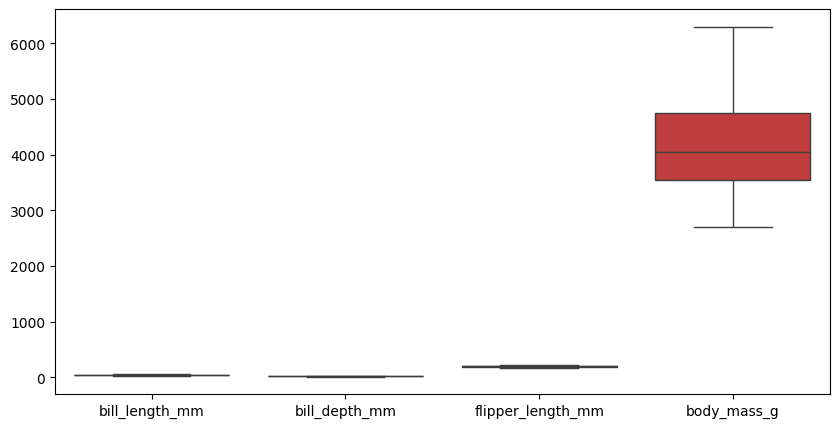

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(data=
penguins[['bill_length_mm',
          'bill_depth_mm',
          'flipper_length_mm',
          'body_mass_g']])

plt.show()

In [ ]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female


In [ ]:
#Model : Predict the type of species based on the features.

In [ ]:
#One hot encoding- island
penguins = pd.get_dummies(
    penguins,
    columns=['island'],
    drop_first=True
)
#Label Encoding- sex
penguins['sex'] = LabelEncoder().fit_transform(
    penguins['sex']
)
#Label encoding - species- Target column
le = LabelEncoder()

penguins['species'] = le.fit_transform(
    penguins['species']
)

In [ ]:
penguins.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Dream,island_Torgersen
0,0,39.10000,18.70000,181.000000,3750.000000,1,False,True
1,0,39.50000,17.40000,186.000000,3800.000000,0,False,True
2,0,40.30000,18.00000,195.000000,3250.000000,0,False,True
3,0,43.92193,17.15117,200.915205,4201.754386,1,False,True
4,0,36.70000,19.30000,193.000000,3450.000000,0,False,True


In [ ]:
#X and Y
X = penguins.drop(
    'species',
    axis=1
)

y = penguins['species']

In [ ]:
y

,species
0,0
1,0
2,0
3,0
4,0
...,...
339,2
340,2
341,2
342,2


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [ ]:
#Preprocessing done


In [ ]:
#Model building.
"""1. Build your model
2. Train the model
3. Test the model
4. Evaluate the model"""
#Step 1: Building the model
knn = KNeighborsClassifier(
    n_neighbors=5
)

#Step 2: Train
knn.fit(
    X_train,
    y_train
)
#Step 3: Test
y_pred = knn.predict(
    X_test
)

In [ ]:
#Step 4: Evaluate
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy*100, "%")

Accuracy: 100.0 %


In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[32  0  0]
 [ 0 16  0]
 [ 0  0 21]]
